Generating IoT Asset Monitoring Flowchart...


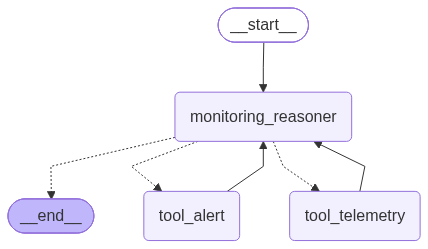


--- Starting IoT Monitoring Cycle ---
Node Executed: monitoring_reasoner
Message: Fetching latest telemetry for MCH-MILL-01...

Node Executed: tool_telemetry
Message: Telemetry for MCH-MILL-01 - Temp: 95°C (Threshold: 85°C), Vibration: Normal.

Node Executed: monitoring_reasoner
Message: Temperature anomaly detected! Triggering system alert.

Node Executed: tool_alert
Message: Critical Alert triggered for MCH-MILL-01. Severity: Critical. Details: Temp exceeded 85°C threshold (Reading: 95°C)

Node Executed: monitoring_reasoner
Message: Monitoring cycle complete. Alert has been logged in the system.



In [1]:
# ---------------------------------------------------------
# 05_IoT_Asset_Monitoring_Agent.ipynb
# LangGraph Implementation for IoT Asset Monitoring
# ---------------------------------------------------------

import operator
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, END, START
from IPython.display import Image, display

# 1. Define the Graph State
class IoTMonitoringState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    machine_id: str
    telemetry_checked: bool
    anomaly_detected: bool
    alert_triggered: bool
    next_step: str

# 2. Mocking Tools (IoT Telemetry & Alerting API mapped to backend_api_table)
def get_telemetry_data(machine_id: str) -> str:
    """Fetches real-time sensor data from the IoT gateway/SCADA."""
    # Mocking a high temperature anomaly for demonstration
    return f"Telemetry for {machine_id} - Temp: 95°C (Threshold: 85°C), Vibration: Normal."

def trigger_alert(machine_id: str, severity: str, details: str) -> str:
    """Inserts a record into alert_master and dispatches a notification."""
    return f"Critical Alert triggered for {machine_id}. Severity: {severity}. Details: {details}"

# 3. Define the Nodes
def monitoring_reasoner(state: IoTMonitoringState):
    """
    Node 1: IoT Monitor Logic.
    Analyzes telemetry and decides if an alert needs to be dispatched.
    """
    # Step A: Fetch Telemetry
    if not state.get('telemetry_checked'):
        return {
            "messages": [AIMessage(content=f"Fetching latest telemetry for {state['machine_id']}...", tool_calls=[{"name": "get_telemetry_data", "args": {"machine_id": state['machine_id']}, "id": "call_tele1"}])],
            "next_step": "tool_telemetry"
        }
    
    # Step B: Evaluate Telemetry for Anomalies
    elif not state.get('alert_triggered'):
        last_msg_content = state['messages'][-1].content
        
        # Simple string matching for our mock logic (LLM would do semantic evaluation here)
        if "Temp: 95°C" in last_msg_content:
            return {
                "messages": [AIMessage(content="Temperature anomaly detected! Triggering system alert.", tool_calls=[{"name": "trigger_alert", "args": {"machine_id": state['machine_id'], "severity": "Critical", "details": "Temp exceeded 85°C threshold (Reading: 95°C)"}, "id": "call_alert1"}])],
                "anomaly_detected": True,
                "next_step": "tool_alert"
            }
        else:
            return {
                "messages": [AIMessage(content="All telemetry metrics are within normal operational limits.")],
                "anomaly_detected": False,
                "next_step": "end"
            }
            
    # Final state after alert
    else:
        return {
            "messages": [AIMessage(content="Monitoring cycle complete. Alert has been logged in the system.")],
            "next_step": "end"
        }

def tool_telemetry(state: IoTMonitoringState):
    """Node 2: Fetch Telemetry Data"""
    last_msg = state['messages'][-1]
    tool_call = last_msg.tool_calls[0]
    result = get_telemetry_data(tool_call['args']['machine_id'])
    
    return {
        "messages": [ToolMessage(content=result, tool_call_id=tool_call['id'])],
        "telemetry_checked": True,
        "next_step": "reasoner"
    }

def tool_alert(state: IoTMonitoringState):
    """Node 3: Trigger System Alert"""
    last_msg = state['messages'][-1]
    tool_call = last_msg.tool_calls[0]
    result = trigger_alert(tool_call['args']['machine_id'], tool_call['args']['severity'], tool_call['args']['details'])
    
    return {
        "messages": [ToolMessage(content=result, tool_call_id=tool_call['id'])],
        "alert_triggered": True,
        "next_step": "reasoner"
    }

# 4. Define Routing Logic
def route_next_step(state: IoTMonitoringState):
    step = state.get("next_step")
    if step == "tool_telemetry": return "tool_telemetry"
    elif step == "tool_alert": return "tool_alert"
    elif step == "end": return END
    return "monitoring_reasoner"

# 5. Build the LangGraph
workflow = StateGraph(IoTMonitoringState)

workflow.add_node("monitoring_reasoner", monitoring_reasoner)
workflow.add_node("tool_telemetry", tool_telemetry)
workflow.add_node("tool_alert", tool_alert)

workflow.add_edge(START, "monitoring_reasoner")

workflow.add_conditional_edges(
    "monitoring_reasoner",
    route_next_step,
    {
        "tool_telemetry": "tool_telemetry",
        "tool_alert": "tool_alert",
        END: END
    }
)

workflow.add_edge("tool_telemetry", "monitoring_reasoner")
workflow.add_edge("tool_alert", "monitoring_reasoner")

app = workflow.compile()

# 6. Render the Graph Visualization
print("Generating IoT Asset Monitoring Flowchart...")
display(Image(app.get_graph().draw_mermaid_png()))

# 7. Execute the Pipeline
print("\n--- Starting IoT Monitoring Cycle ---")
initial_state = {
    "messages": [HumanMessage(content="Initiate diagnostic check on the primary milling machine.")],
    "machine_id": "MCH-MILL-01",
    "telemetry_checked": False,
    "anomaly_detected": False,
    "alert_triggered": False,
    "next_step": ""
}

for output in app.stream(initial_state):
    for key, value in output.items():
        print(f"Node Executed: {key}")
        if "messages" in value:
            print(f"Message: {value['messages'][-1].content}\n")